# Parameter-matching: 1d linear tilt toy

We train a scalar potential $\phi(x, \theta)$ on the elliptic-PDE residual

$$\mathcal{L}(\phi) = \mathbb{E}_{p_\theta(x),\,p(\theta)}\Bigl[\bigl(\partial_\theta \log p_\theta(x) + \Delta_x\phi + \nabla_x\phi\cdot\nabla_x\log p_\theta(x)\bigr)^2\Bigr]$$

for the analytic family $p_\theta(x) = \mathcal{N}(x; 0, 1)\,(1 + \theta\tanh x)$, $\theta \in (-1, 1)$,
where both scores are closed-form (`OracleScore` on both inputs)

1. the recovered velocity $v_\phi = \nabla_x\phi$ matches the continuity-equation
   solution $v(x;\theta) = -\tfrac{1}{p_\theta(x)}\int_{-\infty}^x \partial_\theta p_\theta$
   in $p_\theta$-weighted squared error below $10^{-3}$;
2. ParameterFlow.transport carries samples $p_{\theta_0} \to p_{\theta_1}$;
3. score_supply inverts the PDE back to the joint score.

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pitayasmoothie-dark.mplstyle')
import torch

from nami import (
    RK4,
    LinearParameterPath,
    OracleScore,
    ParameterFlow,
    ScalarPotentialField,
    parameter_flow_loss,
)

torch.manual_seed(7)
generator = torch.Generator().manual_seed(7)

from pm_utils import p0, p_theta, joint_score, spatial_score, sample_p_theta

## The toy family and its closed-form scores

$$\partial_\theta \log p_\theta(x) = \frac{\tanh x}{1 + \theta\tanh x},\qquad
\nabla_x \log p_\theta(x) = -x + \frac{\theta\,\mathrm{sech}^2 x}{1 + \theta\tanh x}$$


## The analytic velocity

Multiplying the PDE by $p_\theta$ gives the continuity equation in $\theta$:

$$\partial_\theta p_\theta + (p_\theta v)' = 0$$

so $v(x;\theta) = -I(x)/p_\theta(x)$ with $I(x) = \int_{-\infty}^x p_0\tanh$.

($I(\infty) = \mathbb{E}_{p_0}[\tanh] = 0$ by symmetry, so $v \to 0$ in the tails.)


In [3]:
def v_analytic_on_grid(grid, theta):
    integrand = p0(grid) * torch.tanh(grid)
    integral = torch.cat(
        [torch.zeros(1, dtype=grid.dtype), torch.cumulative_trapezoid(integrand, grid)]
    )
    return -integral / p_theta(grid, torch.tensor(theta, dtype=grid.dtype))

## Train $\phi$ on the PDE residual


step 0: loss 3.916e-01
step 500: loss 4.688e-04
step 1000: loss 2.142e-04
step 1500: loss 1.939e-04
step 2000: loss 6.270e-05
step 2500: loss 1.040e-04


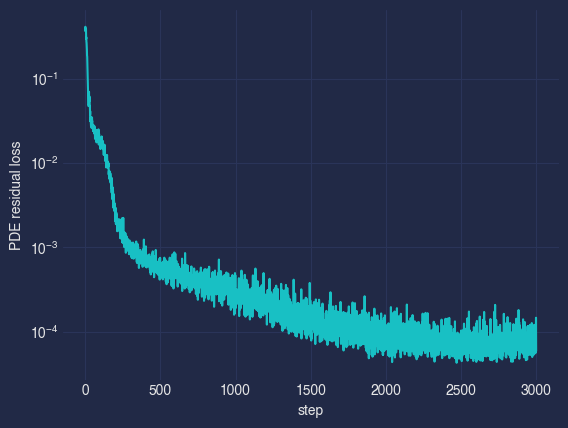

In [8]:
field = ScalarPotentialField(1, theta_dim=1, hidden=64, layers=3)
joint = OracleScore(joint_score)
spatial = OracleScore(spatial_score)

optimizer = torch.optim.Adam(field.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=3000)
losses = []
for step in range(3000):
    theta = torch.rand(512, 1, generator=generator) - 0.5  # U(-0.5, 0.5)
    x = sample_p_theta(theta.squeeze(-1), generator)
    loss = parameter_flow_loss(
        field, x=x, theta=theta, joint_score=joint, spatial_score=spatial
    )
    optimizer.zero_grad(); loss.backward(); optimizer.step(); scheduler.step()
    losses.append(loss.item())
    if step % 500 == 0:
        print(f'step {step}: loss {loss.item():.3e}')

plt.semilogy(losses)
plt.xlabel('step')
plt.ylabel('PDE residual loss')
plt.show()

## $v_\phi$ vs the analytic velocity

$p_\theta$-weighted squared error must be below $10^{-3}$ at each held-out $\theta$.


theta=-0.3: weighted L2 err 5.478e-06  ->  PASS
theta=0.0: weighted L2 err 1.122e-06  ->  PASS
theta=0.4: weighted L2 err 2.085e-06  ->  PASS


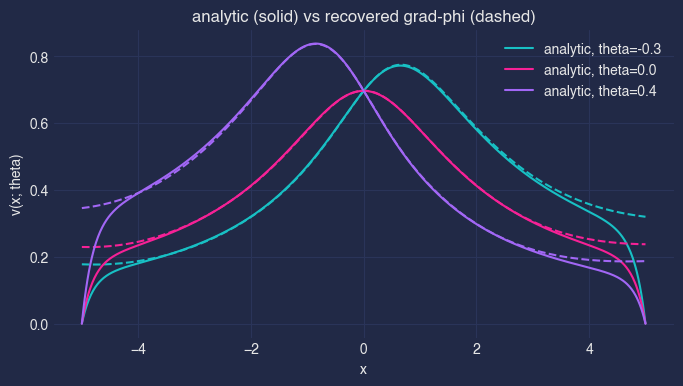

In [5]:
grid = torch.linspace(-5.0, 5.0, 801, dtype=torch.float64)
fig, ax = plt.subplots(figsize=(8, 4))
for theta_eval in (-0.3, 0.0, 0.4):
    v_true = v_analytic_on_grid(grid, theta_eval)
    xs = grid.float().unsqueeze(-1)
    thetas = torch.full((grid.numel(), 1), theta_eval)
    v_model = field.velocity(xs, thetas, create_graph=False).squeeze(-1).double()
    w = p_theta(grid, torch.tensor(theta_eval, dtype=grid.dtype))
    w = w / torch.trapezoid(w, grid)
    err = torch.trapezoid((v_model - v_true) ** 2 * w, grid).item()
    print(f'theta={theta_eval}: weighted L2 err {err:.3e}  ->  '
          f"{'PASS' if err < 1e-3 else 'FAIL'}")
    (line,) = ax.plot(grid, v_true, label=f'analytic, theta={theta_eval}')
    ax.plot(grid, v_model.detach(), '--', color=line.get_color())
ax.set_xlabel('x')
ax.set_ylabel('v(x; theta)')
ax.legend()
ax.set_title('analytic (solid) vs recovered grad-phi (dashed)')
plt.show()

## Transport $p_{\theta_0} \to p_{\theta_1}$

Bind a `LinearParameterPath` and integrate

$$\dot x = \dot\theta(s)\,\nabla_x\phi(x, \theta(s))$$

The transported histogram must overlay the analytic endpoint density.


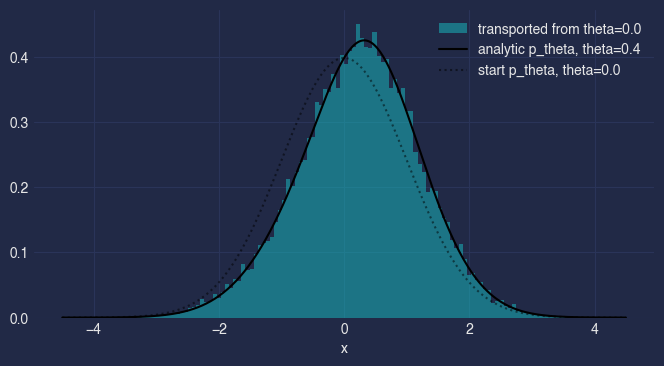

In [6]:
theta_0, theta_1 = 0.0, 0.4
process = ParameterFlow(field, RK4(steps=64))(
    LinearParameterPath(torch.tensor([theta_0]), torch.tensor([theta_1]))
)

x0 = sample_p_theta(torch.full((20000,), theta_0), generator)
with torch.no_grad():
    x1 = process.transport(x0)

grid_f = torch.linspace(-4.5, 4.5, 400, dtype=torch.float64)
plt.figure(figsize=(8, 4))
plt.hist(x1.squeeze(-1).numpy(), bins=120, density=True, alpha=0.5,
         label=f'transported from theta={theta_0}')
plt.plot(grid_f, p_theta(grid_f, torch.tensor(theta_1, dtype=grid_f.dtype)),
         'k-', label=f'analytic p_theta, theta={theta_1}')
plt.plot(grid_f, p_theta(grid_f, torch.tensor(theta_0, dtype=grid_f.dtype)),
         'k:', alpha=0.5, label=f'start p_theta, theta={theta_0}')
plt.legend()
plt.xlabel('x')
plt.show()

## The `score_supply` should invert the PDE

$$\partial_\theta \log\hat p_\theta(x) = -\Delta_x\phi - \nabla_x\phi\cdot\nabla_x\log p_\theta(x)$$

must agree with the joint-score oracle.  Note the spatial score is a required input at evaluation time, whereas the recovery is not autograd through $\phi$ alone.


score_supply RMS error: 1.839e-03


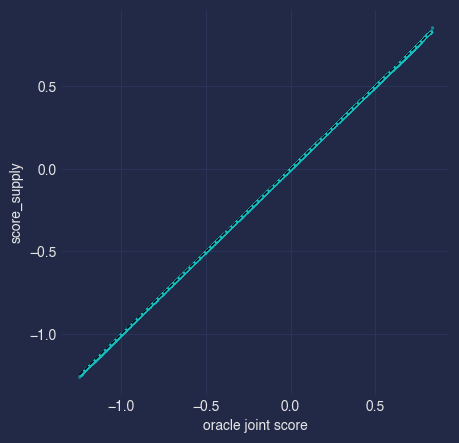

In [7]:
theta_eval = torch.full((4096, 1), 0.2)
x_eval = sample_p_theta(theta_eval.squeeze(-1), generator)
supplied = process.score_supply(x_eval, theta_eval, spatial_score=spatial)
target = joint_score(x_eval, theta_eval)

rms = (supplied - target).pow(2).mean().sqrt().item()
print(f'score_supply RMS error: {rms:.3e}')

plt.figure(figsize=(5, 5))
plt.scatter(target.squeeze(-1), supplied.detach().squeeze(-1), s=2, alpha=0.3)
lims = [target.min().item(), target.max().item()]
plt.plot(lims, lims, 'k--', lw=1)
plt.xlabel('oracle joint score')
plt.ylabel('score_supply')
plt.show()